# Sephora Marketing Analyzer: Analytical Workflow

**Student:** [Shiying Yang]  
**Module:** ACC102 Mini Assignment  
**Track:** 4 – Interactive Data Analysis Tool  
**Dataset:** Sephora Products and Skincare Reviews (Kaggle, accessed 20 April 2026)

## 1. Problem Definition
Beauty e-commerce merchandising and marketing teams need efficient tools to screen products and extract consumer insights from reviews and ingredient data. This notebook documents the analytical workflow behind the Sephora Marketing Analyzer, covering data loading, cleaning, exploratory analysis, ingredient profiling, sentiment keyword extraction, and comprehensive scoring.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Load the cleaned dataset generated by data-prep-new.py
df = pd.read_csv('sephora_ecommerce_cleaned.csv')

# Parse date column
df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')

# Standardize price column
if 'price_usd_y' in df.columns:
    df['price'] = df['price_usd_y']
elif 'price_usd_x' in df.columns:
    df['price'] = df['price_usd_x']
elif 'price_usd' in df.columns:
    df['price'] = df['price_usd']
else:
    df['price'] = 0

# Basic info
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['review_date'].min()} to {df['review_date'].max()}")
df.head(3)

Dataset shape: (487319, 26)
Date range: 2008-09-02 00:00:00 to 2023-03-21 00:00:00


,product_id,product_name,brand_name,review_text,review_title,rating,is_recommended,helpfulness,total_feedback_count,review_date,...,sale_price_usd,rating_product,primary_category,secondary_category,tertiary_category,ingredients,limited_edition,new,sephora_exclusive,price
0,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,I bought this lip mask after reading the revie...,Disappointed,1,0.0,NaN,0,2023-03-21,...,NaN,4.3508,Skincare,Lip Balms & Treatments,NaN,"['Diisostearyl Malate, Hydrogenated Polyisobut...",0,0,1,24.0
1,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,My review title says it all! I get so excited ...,New Favorite Routine,5,1.0,NaN,0,2023-03-21,...,NaN,4.3508,Skincare,Lip Balms & Treatments,NaN,"['Diisostearyl Malate, Hydrogenated Polyisobut...",0,0,1,24.0
2,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,I’ve always loved this formula for a long time...,Can't go wrong with any of them,5,1.0,NaN,0,2023-03-20,...,NaN,4.3508,Skincare,Lip Balms & Treatments,NaN,"['Diisostearyl Malate, Hydrogenated Polyisobut...",0,0,1,24.0


## 2. Data Overview & Quality Check
We verify the structure of the cleaned dataset and check for missing values in key fields.

In [3]:
# Data quality summary
quality_report = pd.DataFrame({
    'Column': df.columns,
    'Non-Null Count': df.count().values,
    'Null Count': df.isnull().sum().values,
    'Dtype': df.dtypes.values
})
display(quality_report)

# Numeric summary
display(df[['rating', 'price', 'helpfulness']].describe())

,Column,Non-Null Count,Null Count,Dtype
0,product_id,487319,0,str
1,product_name,487319,0,str
2,brand_name,487319,0,str
3,review_text,487318,1,str
4,review_title,343619,143700,str
5,rating,487319,0,int64
6,is_recommended,440342,46977,float64
7,helpfulness,246047,241272,float64
8,total_feedback_count,487319,0,int64
9,review_date,487319,0,datetime64[us]


,rating,price,helpfulness
count,487319.000000,487319.000000,246047.000000
mean,4.272113,48.290373,0.771908
std,1.177542,42.408464,0.308904
min,1.000000,3.000000,0.000000
25%,4.000000,24.000000,0.666667
50%,5.000000,39.000000,0.916667
75%,5.000000,60.000000,1.000000
max,5.000000,425.000000,1.000000


## 3. Price Distribution & Tier Analysis
Understanding the price landscape helps merchandising teams position products. We categorize products into three tiers and visualize the distribution.

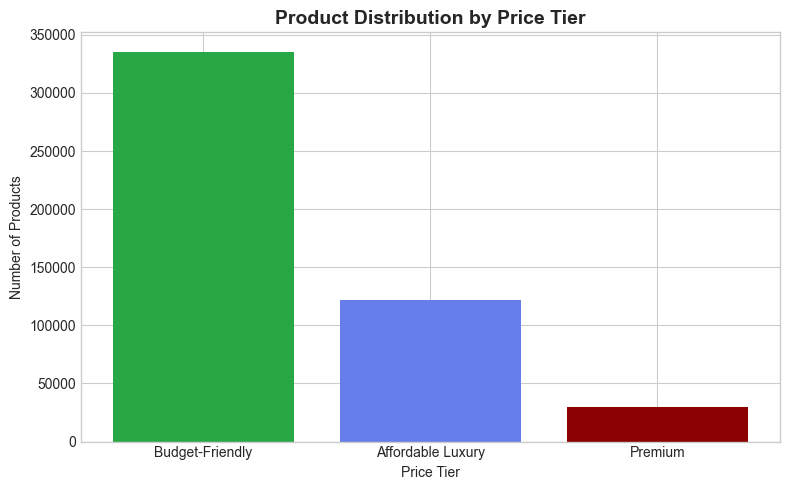

In [4]:
def get_price_tier(price):
    if pd.isna(price):
        return 'Unknown'
    try:
        p = float(price)
        if p <= 50:
            return 'Budget-Friendly'
        elif p <= 100:
            return 'Affordable Luxury'
        else:
            return 'Premium'
    except:
        return 'Unknown'

df['price_tier'] = df['price'].apply(get_price_tier)
tier_counts = df['price_tier'].value_counts().reset_index()
tier_counts.columns = ['Price Tier', 'Count']

plt.figure(figsize=(8, 5))
colors = ['#28a745', '#667eea', '#8B0000']
plt.bar(tier_counts['Price Tier'], tier_counts['Count'], color=colors)
plt.title('Product Distribution by Price Tier', fontsize=14, fontweight='bold')
plt.ylabel('Number of Products')
plt.xlabel('Price Tier')
plt.tight_layout()
plt.show()

## 4. Rating & Review Volume Analysis
We examine the distribution of user ratings and explore the relationship between price and average product rating.

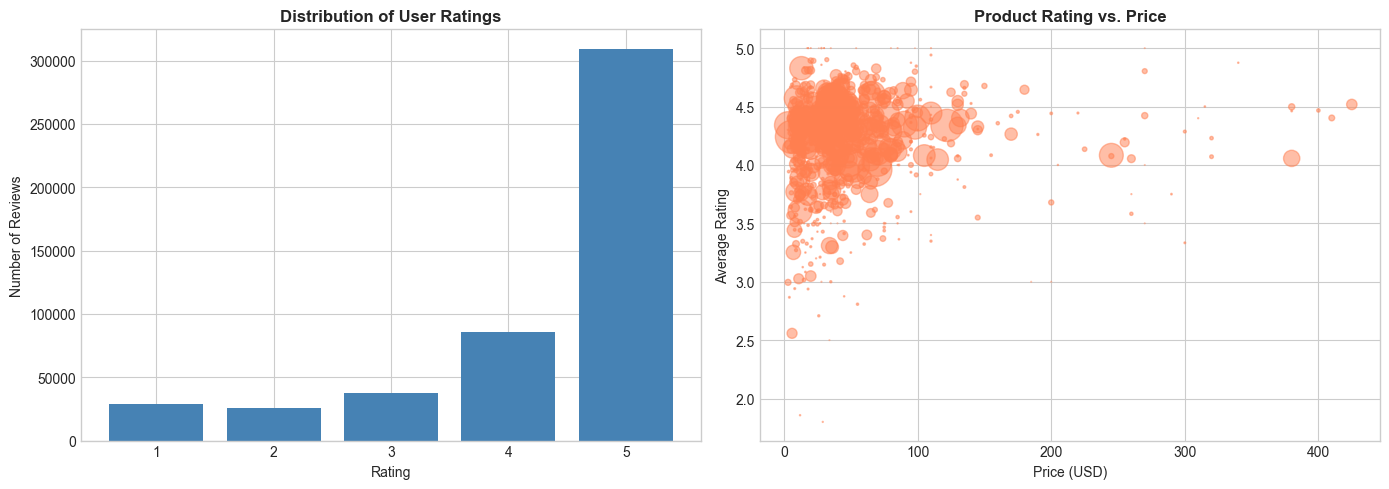

In [5]:
# Rating distribution
rating_dist = df['rating'].value_counts().sort_index().reset_index()
rating_dist.columns = ['Rating', 'Count']

# Product-level aggregation for price-rating relationship
product_stats = df.groupby(['product_name', 'brand_name']).agg({
    'rating': 'mean',
    'price': 'first',
    'review_date': 'count'
}).reset_index().rename(columns={'review_date': 'review_count'})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Rating distribution bar chart
ax1.bar(rating_dist['Rating'], rating_dist['Count'], color='steelblue')
ax1.set_title('Distribution of User Ratings', fontsize=12, fontweight='bold')
ax1.set_xlabel('Rating')
ax1.set_ylabel('Number of Reviews')

# Price vs Rating scatter
ax2.scatter(product_stats['price'], product_stats['rating'], 
           s=product_stats['review_count']/10, alpha=0.5, color='coral')
ax2.set_title('Product Rating vs. Price', fontsize=12, fontweight='bold')
ax2.set_xlabel('Price (USD)')
ax2.set_ylabel('Average Rating')

plt.tight_layout()
plt.show()

## 5. Ingredient Profiling
We identify star performance ingredients and cautionary (sensitizing) ingredients from product formulas to support marketing claims and risk warnings.

Products with ingredient data: 476899
Average star ingredients per product: 1.11


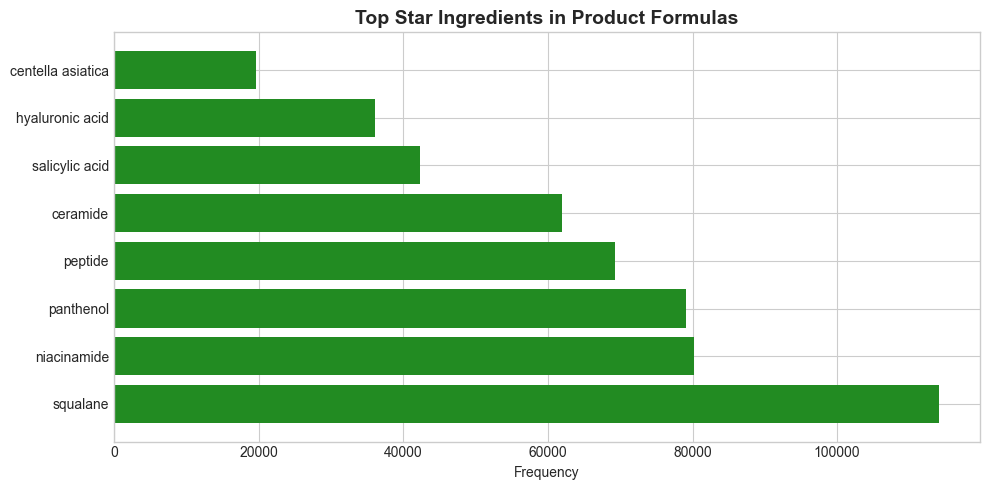

In [6]:
# Simplified ingredient database for demonstration
STAR_INGREDIENTS = ['hyaluronic acid', 'niacinamide', 'retinol', 'vitamin c', 'ceramide', 
                    'squalane', 'peptide', 'salicylic acid', 'centella asiatica', 'panthenol']

def profile_ingredients(text):
    text = str(text).lower()
    return [i for i in STAR_INGREDIENTS if i in text]

# Apply to a sample of products with non-empty ingredients
sample_df = df[df['ingredients'].notna() & (df['ingredients'] != '')].copy()
sample_df['star_ingredients'] = sample_df['ingredients'].apply(profile_ingredients)
sample_df['star_count'] = sample_df['star_ingredients'].apply(len)

print(f"Products with ingredient data: {len(sample_df)}")
print(f"Average star ingredients per product: {sample_df['star_count'].mean():.2f}")

# Top star ingredients frequency
all_stars = [i for sublist in sample_df['star_ingredients'] for i in sublist]
top_stars = Counter(all_stars).most_common(8)

plt.figure(figsize=(10, 5))
ingredients, freqs = zip(*top_stars)
plt.barh(ingredients, freqs, color='forestgreen')
plt.title('Top Star Ingredients in Product Formulas', fontsize=14, fontweight='bold')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

## 6. Skin Type Extraction from Reviews
Since the dataset does not contain explicit skin-type fields, we extract skin-type mentions from review text to understand the dominant user demographic for each product.

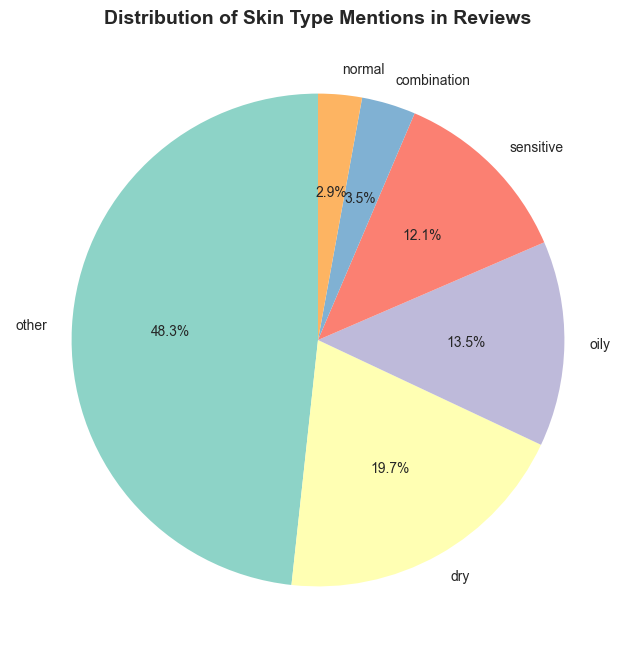

In [7]:
SKIN_KEYWORDS = {
    'oily': ['oily skin', 'oily', 'greasy', 'shine', 'sebum'],
    'dry': ['dry skin', 'dry', 'flaky', 'tight', 'dehydrated'],
    'combination': ['combination skin', 'combination', 'oily t-zone'],
    'sensitive': ['sensitive skin', 'sensitive', 'reactive', 'irritated', 'redness'],
    'normal': ['normal skin', 'normal', 'balanced skin']
}

def extract_skin_type(text):
    text = str(text).lower()
    found = []
    for skin_type, keywords in SKIN_KEYWORDS.items():
        if any(kw in text for kw in keywords):
            found.append(skin_type)
    return found if found else ['other']

# Apply to reviews
df['skin_types_mentioned'] = df['review_text'].apply(extract_skin_type)

# Flatten and count
all_skin = [s for sublist in df['skin_types_mentioned'] for s in sublist]
skin_counts = Counter(all_skin).most_common()

labels, values = zip(*skin_counts)
plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3.colors)
plt.title('Distribution of Skin Type Mentions in Reviews', fontsize=14, fontweight='bold')
plt.show()

## 7. Sentiment Keyword Analysis
Using rule-based keyword matching, we extract frequently mentioned positive and negative themes from review text to identify what consumers value or complain about.

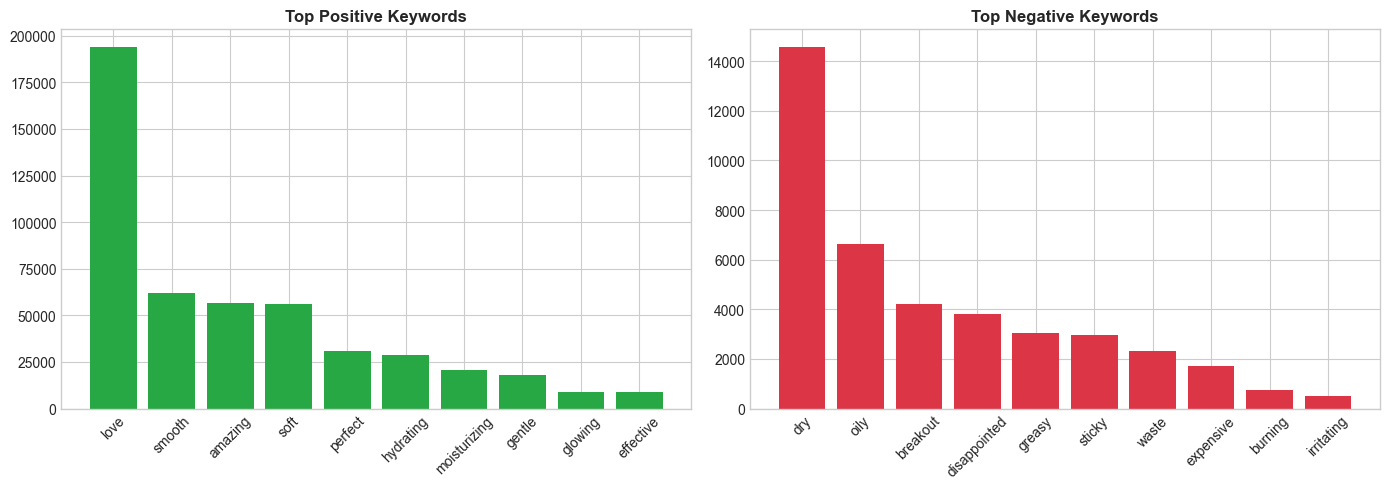

In [8]:
POSITIVE_KEYWORDS = ['hydrating', 'moisturizing', 'smooth', 'brightening', 'effective', 
                     'gentle', 'love', 'perfect', 'excellent', 'amazing', 'soft', 'glowing']
NEGATIVE_KEYWORDS = ['irritating', 'oily', 'sticky', 'expensive', 'waste', 'disappointed', 
                     'breakout', 'allergic', 'dry', 'harsh', 'greasy', 'burning', 'useless']

def extract_keywords(texts, keyword_list):
    counts = Counter()
    for text in texts:
        if pd.notna(text):
            text_lower = str(text).lower()
            for kw in keyword_list:
                counts[kw] += text_lower.count(kw)
    return dict(counts.most_common(10))

pos_texts = df[df['rating'].isin([4, 5])]['review_text']
neg_texts = df[df['rating'].isin([1, 2])]['review_text']

pos_words = extract_keywords(pos_texts, POSITIVE_KEYWORDS)
neg_words = extract_keywords(neg_texts, NEGATIVE_KEYWORDS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(pos_words.keys(), pos_words.values(), color='#28a745')
ax1.set_title('Top Positive Keywords', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

ax2.bar(neg_words.keys(), neg_words.values(), color='#dc3545')
ax2.set_title('Top Negative Keywords', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Comprehensive Score Calculation
To support product selection decisions, we calculate a weighted comprehensive score for each product using four dimensions: rating quality, review popularity, relative price competitiveness, and positive review proportion.

In [9]:
# Recalculate product-level stats
product_scores = df.groupby(['product_name', 'brand_name']).agg({
    'rating': 'mean',
    'price': 'first',
    'review_date': 'count',
    'is_recommended': 'mean' if 'is_recommended' in df.columns else lambda x: (df.loc[x.index, 'rating'] >= 4).mean()
}).reset_index().rename(columns={'review_date': 'review_count'})

# Handle is_recommended fallback
if 'is_recommended' not in df.columns:
    product_scores['is_recommended'] = df.groupby(['product_name', 'brand_name'])['rating'].apply(lambda x: (x >= 4).mean()).values

# Category average price for value comparison
category_avg = product_scores['price'].mean()

def calc_score(row):
    rating_s = (row['rating'] / 5) * 5 * 0.40
    pop_s = min(row['review_count'] / 1000, 1) * 5 * 0.25
    value_s = min(category_avg / row['price'], 1) * 5 * 0.20 if row['price'] > 0 else 2.5
    rec_s = row['is_recommended'] * 5 * 0.15
    return round(rating_s + pop_s + value_s + rec_s, 1)

product_scores['comprehensive_score'] = product_scores.apply(calc_score, axis=1)
product_scores = product_scores.sort_values('comprehensive_score', ascending=False)

print("Top 10 Products by Comprehensive Score:")
display(product_scores.head(10)[['product_name', 'brand_name', 'rating', 'review_count', 'price', 'comprehensive_score']])

Top 10 Products by Comprehensive Score:


,product_name,brand_name,rating,review_count,price,comprehensive_score
300,Facial Cotton,Shiseido,4.828308,2819,13.0,4.9
28,AHA 30% + BHA 2% Exfoliating Peeling Solution,The Ordinary,4.571162,3218,9.5,4.8
756,Urban Environment Fresh-Moisture Sunscreen Bro...,Shiseido,4.633790,1095,38.0,4.8
502,Original Skin Retexturizing Mask with Rose Clay,Origins,4.619615,1764,32.0,4.8
205,Clear Improvement Charcoal Honey Mask to Purif...,Origins,4.645251,1074,37.0,4.8
208,Clear Sunscreen Stick SPF 50+,Shiseido,4.654305,1510,30.0,4.8
87,Barrier+ Foaming Oil Hydrating Cleanser,Skinfix,4.579899,995,30.0,4.8
711,The True Cream Moisturizing Bomb,belif,4.562305,4494,38.0,4.8
170,Cica Sleeping Mask,LANEIGE,4.636643,977,34.0,4.8
791,Watermelon Glow Hyaluronic Clay Pore-Tight Fac...,Glow Recipe,4.589560,977,40.0,4.8


## 9. Key Insights & Limitations

### Insights
- The price tier analysis reveals the market segmentation across budget, mid-range, and premium beauty products.
- Star ingredients like hyaluronic acid and niacinamide appear most frequently, aligning with consumer demand for hydration and brightening.
- Skin-type extraction indicates that combination and dry skin users are the most vocal reviewers, suggesting these segments drive review volume.
- Positive keywords center on hydration and gentleness, while negative keywords frequently mention price and irritation concerns.

### Limitations
- Rule-based keyword matching cannot capture nuanced sentiment or sarcasm.
- Skin-type data is inferred from review text rather than explicitly provided by users, introducing extraction bias.
- The dataset is limited to Sephora listings and may not generalize to the broader beauty market.
- The tool supports single-product analysis only; cross-product or temporal trend modeling is not implemented.

### Possible Improvements
- Upgrade to machine-learning-based sentiment analysis for richer emotional detection.
- Introduce competitor comparison modules.
- Integrate real-time data feeds to keep insights current.